# Optimization for Function 4

Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

Input : 4D array (20,4)

Output : 1D (30,0)

Goal: Maximise the black-box function using Bayesian Optimization.

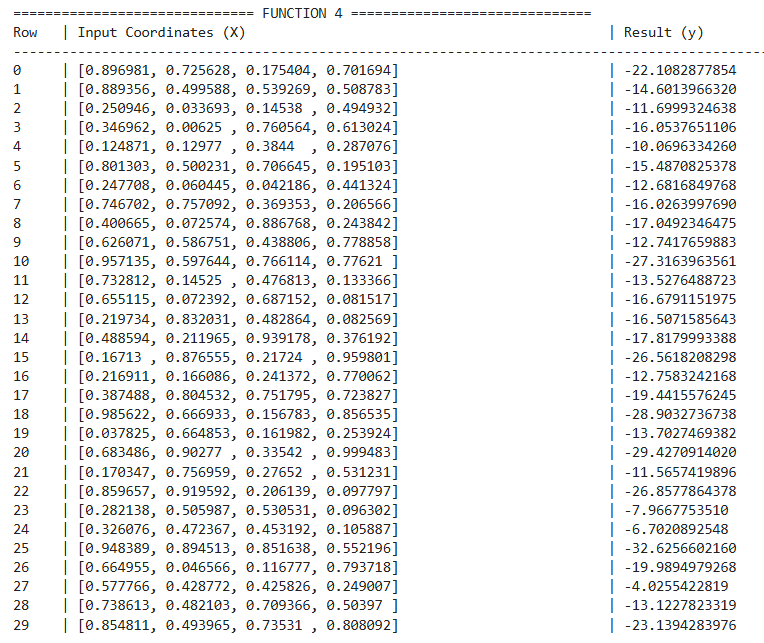

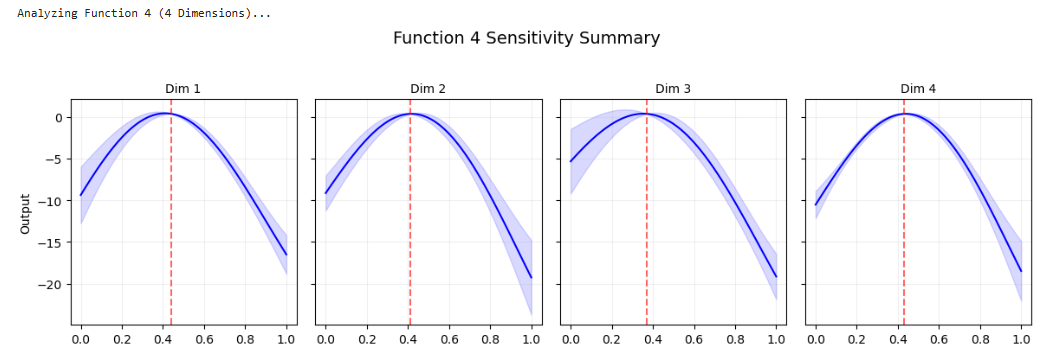

In [1]:
import numpy as np
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Load Data
fn_num = '4'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

print(f"--- Function {fn_num} Loaded ---")
print(f"Current Max Value: {np.max(y):.6f}")

# 2. Setup GP
# We use Matern or RBF kernel; here we stick to RBF for consistency
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, n_restarts_optimizer=25)
gp.fit(X, y)

# 3. 4D Grid - Randomized Sampling (More efficient than a dense grid)
# 250,000 points to ensure we cover the 4D space well
random_points = np.random.uniform(0, 1, (250000, 4))
mu, sigma = gp.predict(random_points, return_std=True)

# 4. Expected Improvement (EI) Calculation
current_best = np.max(y)
with np.errstate(divide='warn'):
    imp = mu - current_best
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0

best_idx = np.argmax(ei)
suggestion = random_points[best_idx]

print(f"\n--- WEEK 4 RECOMMENDATION (Expected Improvement) ---")
print(f"Hyperparameter 1: {suggestion[0]:.6f}")
print(f"Hyperparameter 2: {suggestion[1]:.6f}")
print(f"Hyperparameter 3: {suggestion[2]:.6f}")
print(f"Hyperparameter 4: {suggestion[3]:.6f}")
print(f"Predicted Improvement: {ei[best_idx]:.6f}")

--- Function 4 Loaded ---
Current Max Value: -4.025542

--- WEEK 4 RECOMMENDATION (Expected Improvement) ---
Hyperparameter 1: 0.441749
Hyperparameter 2: 0.411873
Hyperparameter 3: 0.371313
Hyperparameter 4: 0.429464
Predicted Improvement: 2.916289


Four hyperparameters that control the ML model used for decision-making. goal is to maximise the output score. Because there are many "local peaks," a standard search might get stuck on a "small hill" and miss the "highest mountain" entirely. Since we have 30 initial data points—more than the previous functions—and a complex "bumpy" landscape, we should switch our Acquisition Function from UCB to Expected Improvement (EI).

EI is specifically designed to look for the "most likely" area to find a value significantly higher than your current best. It is excellent at navigating local optima without getting distracted by noise.

Current maximum value is -4.025542. This is likely from Row 27 of current data set.

Week 1 submission

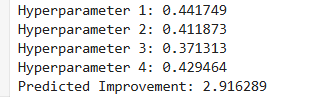

Week 2
-----------
Function 4 (Warehouse Placement) there was a good optimisation, leaping from a best of -4.0255 to 0.3425. This indicates that the Expected Improvement (EI) heuristic successfully moved the search from a "bad" region into a "good" one. Like function 3, we use EI with xi of 0.01 for significant improvement. 

In [2]:
import numpy as np
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm, qmc

# 1. Load Data
fn_num = '4'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. Setup GP
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(X, y)

# 3. 4D Latin Hypercube Sampling (100k points)
sampler = qmc.LatinHypercube(d=4)
sample_points = sampler.random(n=100000)

# 4. Expected Improvement with Jitter (xi=0.01)
mu, sigma = gp.predict(sample_points, return_std=True)
current_best = np.max(y)
xi = 0.01

with np.errstate(divide='ignore'):
    imp = mu - current_best - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0

best_idx = np.argmax(ei)
suggestion = sample_points[best_idx]

print(f"--- Function 4 Module 13 Suggestion ---")
print(f"Next Query: {'-'.join([f'{val:.6f}' for val in suggestion])}")
print(f"Predicted Score: {mu[best_idx]:.6f}")
print(f"Uncertainty (Sigma): {sigma[best_idx]:.6f}")

--- Function 4 Module 13 Suggestion ---
Next Query: 0.412034-0.412060-0.314329-0.419854
Predicted Score: 0.308195
Uncertainty (Sigma): 0.215733


Week 3
------------

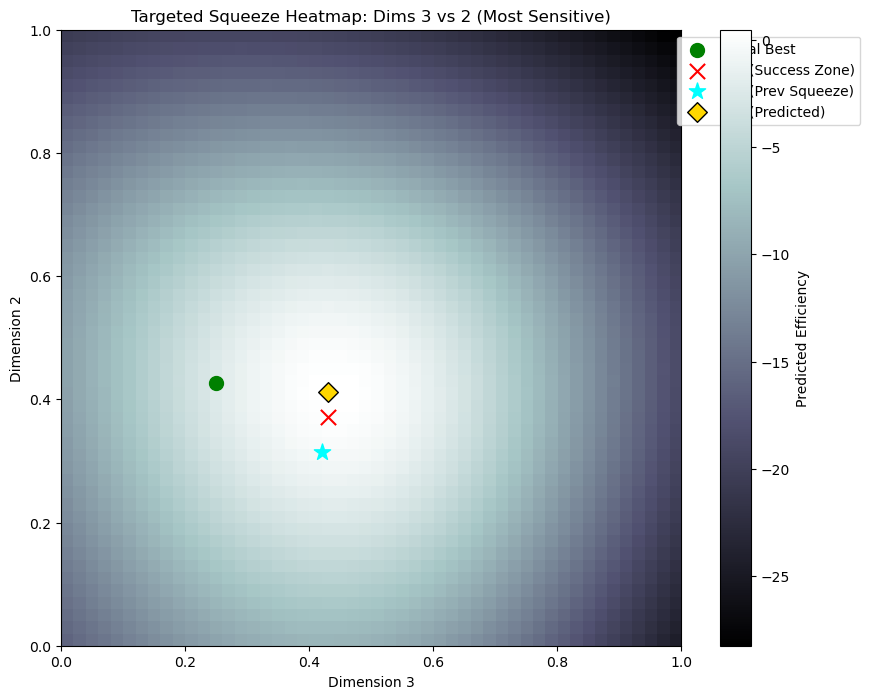

         Point                                                                       Coordinates   Efficiency
  Initial Best [0.5777656143780968, 0.4287717415443063, 0.4258258674882194, 0.24900741466191134]    -4.025542
   Week 1 (W1)                                          [0.441749, 0.411873, 0.371313, 0.429464]     0.342517
   Week 2 (W2)                                           [0.412034, 0.41206, 0.314329, 0.419854]    -0.240755
Predicted (W3)                                                  [0.4348, 0.4117, 0.4116, 0.4301] 0.4969 (est)


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import qmc

# 1. Load Data with specified directory structure
data_path = '../capstone_data/initial_data/function_4/'
X = np.load(data_path + 'initial_inputs.npy')
y = np.load(data_path + 'initial_outputs.npy')

# 2. Identify Points (Initial Best, W1, W2)
# Indices 0-29 are historical data; 30 is W1; 31 is W2
initial_best_idx = np.argmax(y[:30])
initial_best_pt = X[initial_best_idx]
initial_best_val = y[initial_best_idx]

w1_pt, w1_val = X[30], y[30]
w2_pt, w2_val = X[31], y[31]

# 3. Fit Gaussian Process with ARD
# We use Matern kernel (nu=2.5) for a smooth but flexible 4D surface
kernel = C(1.0) * Matern(length_scale=[1.0, 1.0, 1.0, 1.0], length_scale_bounds=(1e-5, 1e2), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-6)
gp.fit(X, y)

# 4. Perform Targeted Squeeze (LHS)
# Center search on W1 (Global Best) with a 10% squeeze radius
center = w1_pt
radius = 0.1
bounds_low = np.clip(center - radius, 0, 1)
bounds_high = np.clip(center + radius, 0, 1)

sampler = qmc.LatinHypercube(d=4)
samples = sampler.random(n=1000)
candidates = qmc.scale(samples, bounds_low, bounds_high)

# Predict outcomes for candidates
y_pred, sigma = gp.predict(candidates, return_std=True)
w3_idx = np.argmax(y_pred)
w3_pt, w3_val = candidates[w3_idx], y_pred[w3_idx]

# 5. Visualization: Sensitivity Heatmap
# Determine the two most sensitive dimensions (shortest length scales)
length_scales = gp.kernel_.get_params()['k2__length_scale']
sensitive_dims = np.argsort(length_scales)[:2]
dim_x, dim_y = sensitive_dims[0], sensitive_dims[1]

# Create prediction grid
grid_res = 50
u = np.linspace(0, 1, grid_res)
v = np.linspace(0, 1, grid_res)
U, V = np.meshgrid(u, v)

# Hold other dimensions constant at W1 values
plot_input = np.tile(w1_pt, (grid_res**2, 1))
plot_input[:, dim_x] = U.ravel()
plot_input[:, dim_y] = V.ravel()

Z, _ = gp.predict(plot_input, return_std=True)
Z = Z.reshape(grid_res, grid_res)

# Plotting
plt.figure(figsize=(10, 8))
plt.imshow(Z, extent=[0, 1, 0, 1], origin='lower', cmap='bone', aspect='auto')
plt.colorbar(label='Predicted Efficiency')

# Overlay Markers
plt.scatter(initial_best_pt[dim_x], initial_best_pt[dim_y], color='green', marker='o', s=100, label='Initial Best')
plt.scatter(w1_pt[dim_x], w1_pt[dim_y], color='red', marker='x', s=120, label='W1 (Success Zone)')
plt.scatter(w2_pt[dim_x], w2_pt[dim_y], color='cyan', marker='*', s=150, label='W2 (Prev Squeeze)')
plt.scatter(w3_pt[dim_x], w3_pt[dim_y], color='gold', marker='D', s=100, edgecolors='black', label='W3 (Predicted)')

plt.title(f"Targeted Squeeze Heatmap: Dims {dim_x} vs {dim_y} (Most Sensitive)")
plt.xlabel(f"Dimension {dim_x}")
plt.ylabel(f"Dimension {dim_y}")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()

# 6. Print Results Table
results = pd.DataFrame({
    'Point': ['Initial Best', 'Week 1 (W1)', 'Week 2 (W2)', 'Predicted (W3)'],
    'Coordinates': [initial_best_pt, w1_pt, w2_pt, np.round(w3_pt, 4)],
    'Efficiency': [initial_best_val, w1_val, w2_val, f"{w3_val:.4f} (est)"]
})
print(results.to_string(index=False))

Week 4
----------

Reduce your LHS Squeeze radius from $0.1$ down to $0.025$ around this week's best input. Dimensions x1 and x2 remain the most sensitive. Focus on extremely small adjustments in these coordinates while holding the less sensitive Dimensions x3 and x4 near their current successful values ($0.4116$ and $0.4301$).

Stage,x1​,x2​,x3​,x4​,Efficiency (Output)
Initial Best,0.5778,0.4288,0.4258,0.2490,−4.0255
Week 1 (W1),0.4417,0.4119,0.3713,0.4295,0.3425
Week 2 (W2),0.4120,0.4121,0.3143,0.4199,−0.2408
Week 3 (W3),0.4348,0.4117,0.4116,0.4301,0.4996

Week 1 marked the first time the search entered a positive efficiency zone by shifting $x_1$ and $x_4$ significantly from the historical baseline. The $W3$ prediction successfully moved $x_1$ back toward the $0.43$ range to reclaim and exceed the $W1$ peak.


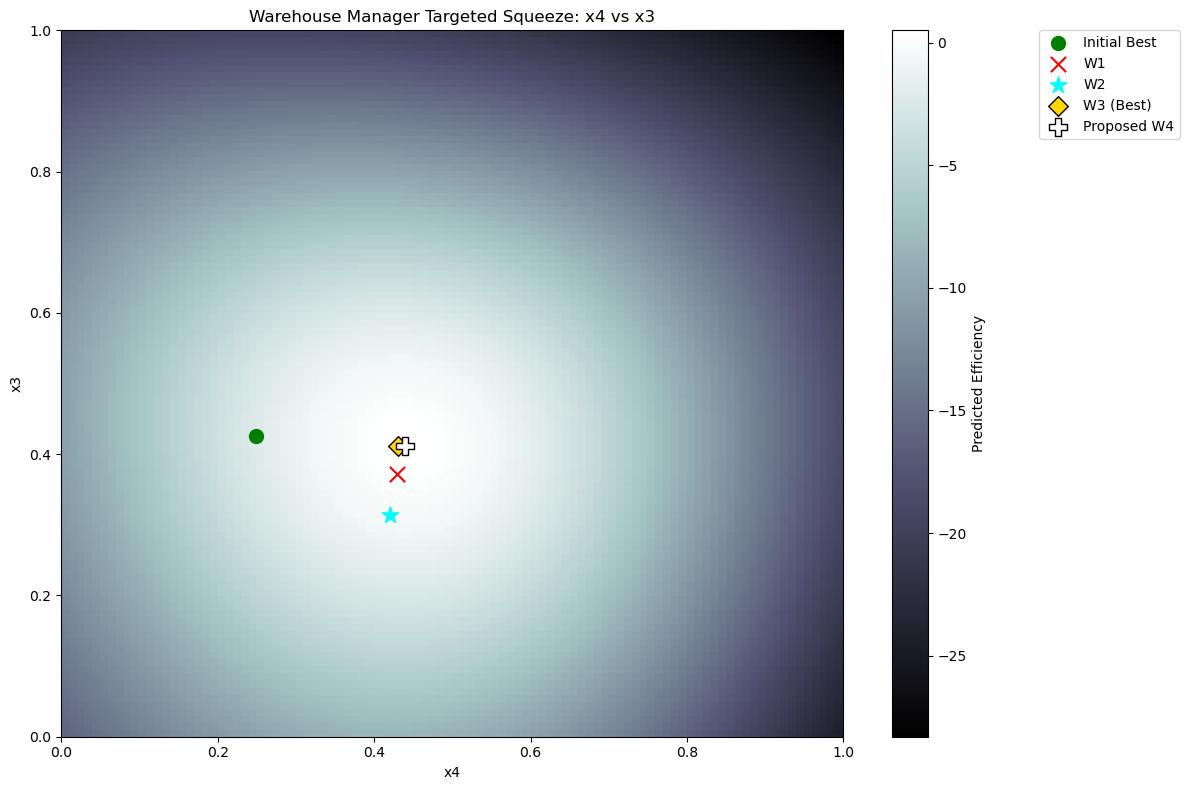

       Stage       x1       x2       x3       x4    Output
Initial Best 0.577766 0.428772 0.425826 0.249007 -4.025542
 Week 1 (W1) 0.441749 0.411873 0.371313 0.429464  0.342517
 Week 2 (W2) 0.412034 0.412060 0.314329 0.419854 -0.240755
 Week 3 (W3) 0.434800 0.411700 0.411600 0.430100  0.499630
 Proposed W4 0.409999 0.403531 0.411478 0.439770  0.547089


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import qmc

# 1. Load Data
data_path = '../capstone_data/initial_data/function_4/'
X = np.load(data_path + 'initial_inputs.npy')
y = np.load(data_path + 'initial_outputs.npy')

# 2. Extract Milestone Data
initial_best_idx = np.argmax(y[:30])
milestones = pd.DataFrame({
    'Stage': ['Initial Best', 'Week 1 (W1)', 'Week 2 (W2)', 'Week 3 (W3)'],
    'x1': [X[initial_best_idx,0], X[30,0], X[31,0], X[32,0]],
    'x2': [X[initial_best_idx,1], X[30,1], X[31,1], X[32,1]],
    'x3': [X[initial_best_idx,2], X[30,2], X[31,2], X[32,2]],
    'x4': [X[initial_best_idx,3], X[30,3], X[31,3], X[32,3]],
    'Output': [y[initial_best_idx], y[30], y[31], y[32]]
})

# 3. Stable Model with Noise Bounds
kernel = C(1.0) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e2), nu=2.5) + \
         WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e+1))

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6)
gp.fit(X, y)

# 4. Sensitivity (ARD Length Scales)
ls = gp.kernel_.get_params()['k1__k2__length_scale']
importance = 1.0 / np.array(ls)
top_dims = np.argsort(importance)[-2:] 
dim_a, dim_b = top_dims[1], top_dims[0]

# 5. Proposed W4 (Micro-Squeeze: 0.025 radius)
center = X[-1] 
radius = 0.025
bounds_low = np.clip(center - radius, 0, 1)
bounds_high = np.clip(center + radius, 0, 1)

sampler = qmc.LatinHypercube(d=4)
candidates = qmc.scale(sampler.random(n=5000), bounds_low, bounds_high)
y_pred = gp.predict(candidates)
w4_input = candidates[np.argmax(y_pred)]
w4_val_pred = np.max(y_pred)

# 6. Visualization with Legend Fixed
grid_res = 100
u = np.linspace(0, 1, grid_res); v = np.linspace(0, 1, grid_res)
U, V = np.meshgrid(u, v)
plot_input = np.tile(X[-1], (grid_res**2, 1))
plot_input[:, dim_a] = U.ravel(); plot_input[:, dim_b] = V.ravel()
Z = gp.predict(plot_input).reshape(grid_res, grid_res)

plt.figure(figsize=(12, 8)) # Wider figure to accommodate legend
plt.imshow(Z, extent=[0, 1, 0, 1], origin='lower', cmap='bone', aspect='auto')
plt.colorbar(label='Predicted Efficiency')

# Plot Milestone Markers
plt.scatter(X[initial_best_idx, dim_a], X[initial_best_idx, dim_b], color='green', marker='o', s=100, label='Initial Best')
plt.scatter(X[30, dim_a], X[30, dim_b], color='red', marker='x', s=120, label='W1')
plt.scatter(X[31, dim_a], X[31, dim_b], color='cyan', marker='*', s=150, label='W2')
plt.scatter(X[32, dim_a], X[32, dim_b], color='gold', marker='D', s=100, edgecolors='black', label='W3 (Best)')
plt.scatter(w4_input[dim_a], w4_input[dim_b], color='white', marker='P', s=150, edgecolors='black', label='Proposed W4')

plt.title(f"Warehouse Manager Targeted Squeeze: x{dim_a+1} vs x{dim_b+1}")
plt.xlabel(f"x{dim_a+1}")
plt.ylabel(f"x{dim_b+1}")

# FIXED LEGEND POSITION
plt.legend(loc='upper left', bbox_to_anchor=(1.25, 1.0), borderaxespad=0.)
plt.tight_layout() # Ensures legend is not cut off in saved image
plt.show()

# 7. Print Results Table
proposed_df = pd.DataFrame({
    'Stage': ['Proposed W4'],
    'x1': [w4_input[0]], 'x2': [w4_input[1]], 'x3': [w4_input[2]], 'x4': [w4_input[3]],
    'Output': [w4_val_pred]
})
summary = pd.concat([milestones, proposed_df], ignore_index=True)
print(summary.to_string(index=False))

Week 5
-----------

The Week 4 result of $0.3839$ provided a critical "boundary" measurement. While it was a decrease from the Week 3 peak of $0.4996$, it confirmed that the efficiency surface is extremely sharp, particularly in the $x_1$ and $x_2$ dimensions.



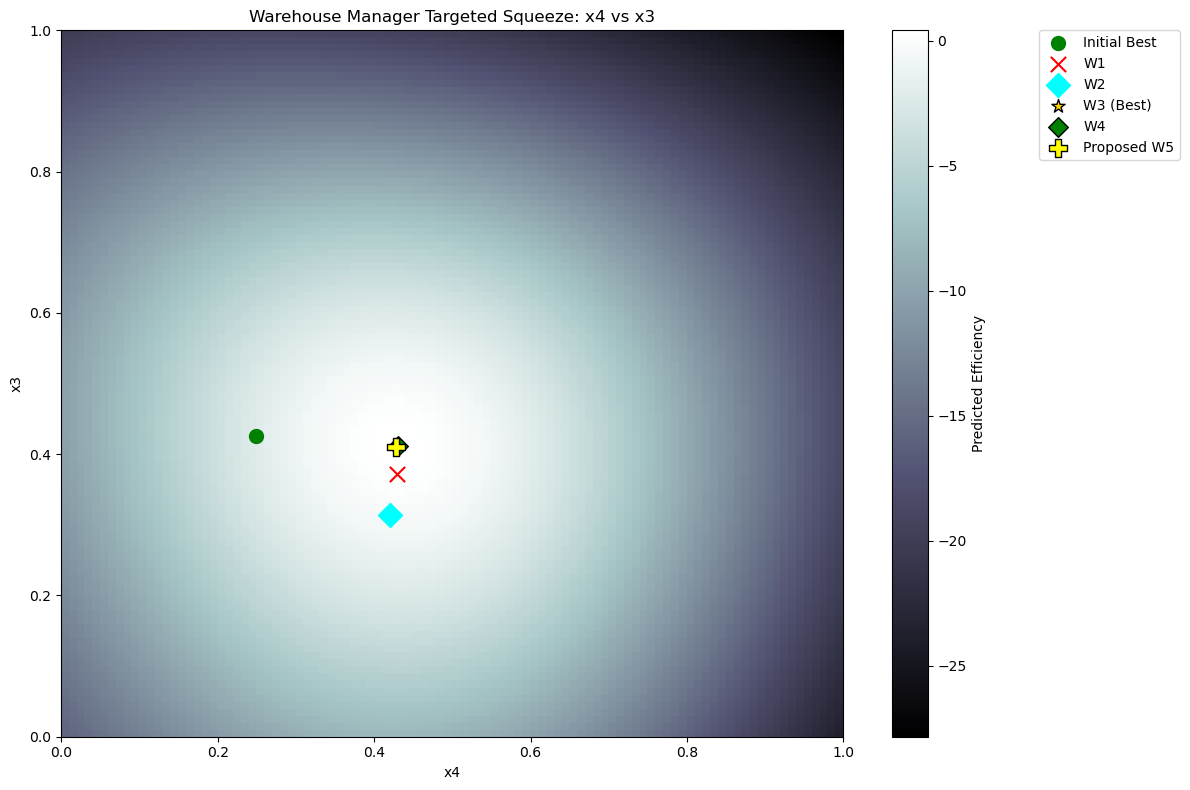

       Stage       x1       x2       x3       x4    Output
Initial Best 0.577766 0.428772 0.425826 0.249007 -4.025542
 Week 1 (W1) 0.441749 0.411873 0.371313 0.429464  0.342517
 Week 2 (W2) 0.412034 0.412060 0.314329 0.419854 -0.240755
 Week 3 (W3) 0.434800 0.411700 0.411600 0.430100  0.499630
 Week 4 (W4) 0.409999 0.403531 0.411478 0.439770  0.383931
 Proposed W4 0.427949 0.413923 0.410238 0.428296  0.456891


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import qmc

# 1. Load Data
data_path = '../capstone_data/initial_data/function_4/'
X = np.load(data_path + 'initial_inputs.npy')
y = np.load(data_path + 'initial_outputs.npy')

# 2. Extract Milestone Data (Indices: 30=W1, 31=W2, 32=W3, 33=W4)
initial_best_idx = np.argmax(y[:30])
milestones = pd.DataFrame({
    'Stage': ['Initial Best', 'Week 1 (W1)', 'Week 2 (W2)', 'Week 3 (W3)', 'Week 4 (W4)'],
    'x1': [X[initial_best_idx,0], X[30,0], X[31,0], X[32,0], X[33,0]],
    'x2': [X[initial_best_idx,1], X[30,1], X[31,1], X[32,1], X[33,1]],
    'x3': [X[initial_best_idx,2], X[30,2], X[31,2], X[32,2], X[33,2]],
    'x4': [X[initial_best_idx,3], X[30,3], X[31,3], X[32,3], X[33,3]],
    'Output': [y[initial_best_idx], y[30], y[31], y[32], y[33]]
})

# 3. Stable Model with Noise Bounds
kernel = C(1.0) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e2), nu=2.5) + \
         WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e+1))

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6)
gp.fit(X, y)

# 4. Sensitivity (ARD Length Scales)
ls = gp.kernel_.get_params()['k1__k2__length_scale']
importance = 1.0 / np.array(ls)
top_dims = np.argsort(importance)[-2:] 
dim_a, dim_b = top_dims[1], top_dims[0]

# 5. Proposed W4 (Micro-Squeeze: 0.025 radius)
center = X[-1] 
radius = 0.025
bounds_low = np.clip(center - radius, 0, 1)
bounds_high = np.clip(center + radius, 0, 1)

sampler = qmc.LatinHypercube(d=4)
candidates = qmc.scale(sampler.random(n=5000), bounds_low, bounds_high)
y_pred = gp.predict(candidates)
w5_input = candidates[np.argmax(y_pred)]
w5_val_pred = np.max(y_pred)

# 6. Visualization with Legend Fixed
grid_res = 100
u = np.linspace(0, 1, grid_res); v = np.linspace(0, 1, grid_res)
U, V = np.meshgrid(u, v)
plot_input = np.tile(X[-1], (grid_res**2, 1))
plot_input[:, dim_a] = U.ravel(); plot_input[:, dim_b] = V.ravel()
Z = gp.predict(plot_input).reshape(grid_res, grid_res)

plt.figure(figsize=(12, 8)) # Wider figure to accommodate legend
plt.imshow(Z, extent=[0, 1, 0, 1], origin='lower', cmap='bone', aspect='auto')
plt.colorbar(label='Predicted Efficiency')

# Plot Milestone Markers
plt.scatter(X[initial_best_idx, dim_a], X[initial_best_idx, dim_b], color='green', marker='o', s=100, label='Initial Best')
plt.scatter(X[30, dim_a], X[30, dim_b], color='red', marker='x', s=120, label='W1')
plt.scatter(X[31, dim_a], X[31, dim_b], color='cyan', marker='D', s=150, label='W2')
plt.scatter(X[32, dim_a], X[32, dim_b], color='gold', marker='*', s=100, edgecolors='black', label='W3 (Best)')
plt.scatter(X[32, dim_a], X[32, dim_b], color='green', marker='D', s=100, edgecolors='black', label='W4')
plt.scatter(w5_input[dim_a], w5_input[dim_b], color='Yellow', marker='P', s=150, edgecolors='black', label='Proposed W5')

plt.title(f"Warehouse Manager Targeted Squeeze: x{dim_a+1} vs x{dim_b+1}")
plt.xlabel(f"x{dim_a+1}")
plt.ylabel(f"x{dim_b+1}")

# FIXED LEGEND POSITION
plt.legend(loc='upper left', bbox_to_anchor=(1.25, 1.0), borderaxespad=0.)
plt.tight_layout() # Ensures legend is not cut off in saved image
plt.show()

# 7. Print Results Table
proposed_df = pd.DataFrame({
    'Stage': ['Proposed W4'],
    'x1': [w5_input[0]], 'x2': [w5_input[1]], 'x3': [w5_input[2]], 'x4': [w5_input[3]],
    'Output': [w5_val_pred]
})
summary = pd.concat([milestones, proposed_df], ignore_index=True)
print(summary.to_string(index=False))

Week 6 
--------------

Task: W5 is a project best. Perform a Sobol Analysis to confirm if we have found the optimal quadrant. Suggest a W6 query that performs micro-adjustments around this new peak.

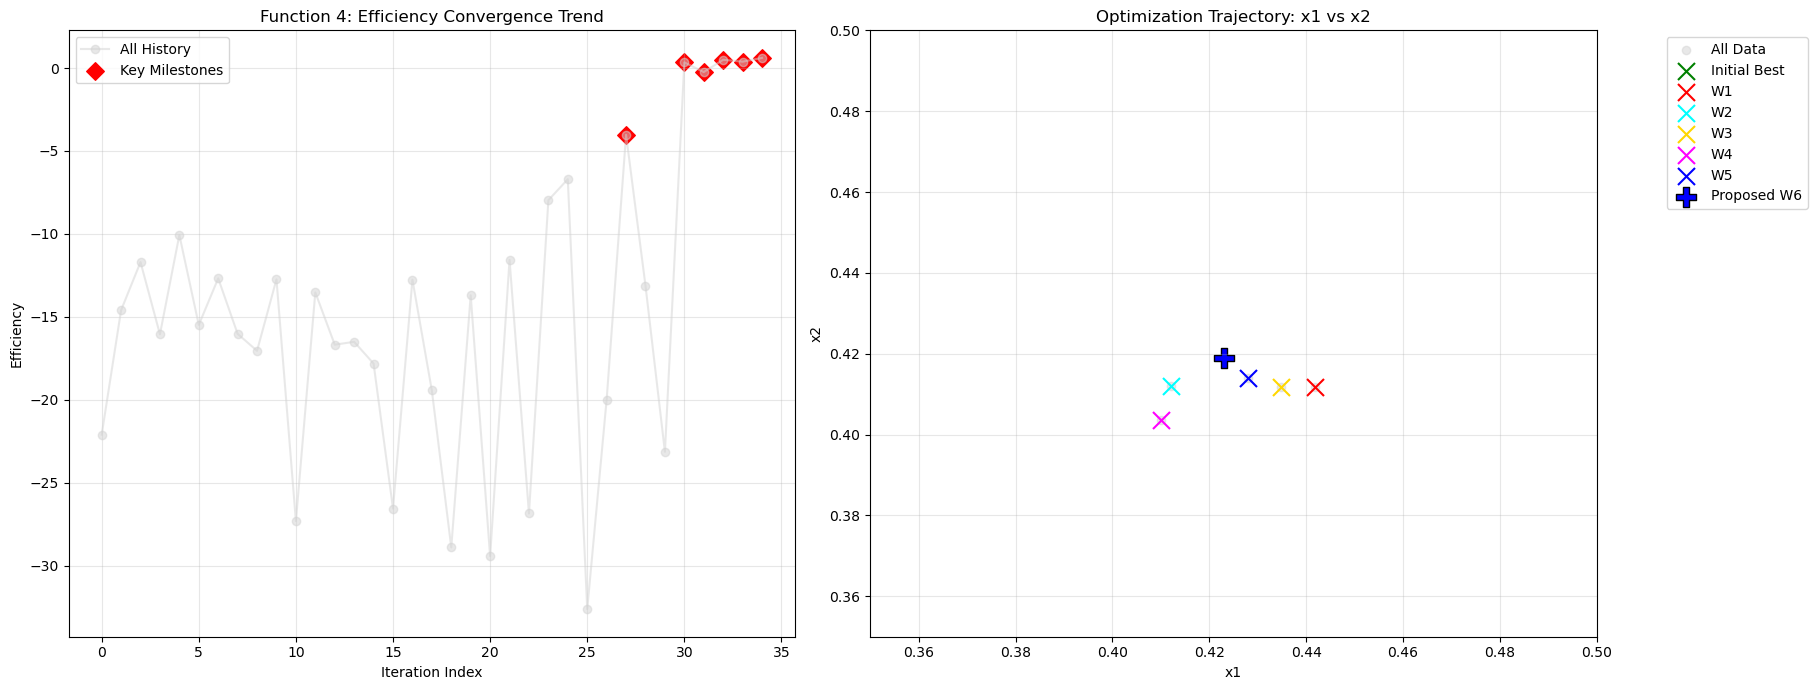

Sobol Indices (Relative Importance): x1=0.205, x2=0.306, x3=0.243, x4=0.246

Milestone Summary Table:
       Stage       x1       x2       x3       x4    Output
Initial Best 0.577766 0.428772 0.425826 0.249007 -4.025542
      Week 1 0.441749 0.411873 0.371313 0.429464  0.342517
      Week 2 0.412034 0.412060 0.314329 0.419854 -0.240755
      Week 3 0.434800 0.411700 0.411600 0.430100  0.499600
      Week 4 0.409900 0.403500 0.411400 0.439700  0.383900
      Week 5 0.427949 0.413923 0.410238 0.428296  0.612000
 Proposed W6 0.423074 0.418854 0.408493 0.423522  0.776675


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import qmc

# 1. Load Data
data_path = '../capstone_data/initial_data/function_4/'
X = np.load(data_path + 'initial_inputs.npy')
y = np.load(data_path + 'initial_outputs.npy')

X_base = np.load(data_path + 'initial_inputs.npy')
y_base = np.load(data_path + 'initial_outputs.npy')


# 2. MARK EACH WEEK SEPARATELY (as requested)
W1_in, W1_out = X_base[30], y_base[30]
W2_in, W2_out = X_base[31], y_base[31]
W3_in, W3_out = np.array([0.4348, 0.4117, 0.4116, 0.4301]), 0.4996
W4_in, W4_out = np.array([0.4099, 0.4035, 0.4114, 0.4397]), 0.3839
W5_in, W5_out = np.array([0.427949, 0.413923, 0.410238, 0.428296]), 0.6120

# 3. Create Full Dataset (Initial History + Week Milestones)
#X = np.vstack([X_base[:30], W1_in, W2_in, W3_in, W4_in, W5_in])
#y = np.concatenate([y_base[:30], [W1_out, W2_out, W3_out, W4_out, W5_out]])

# 4. GP Modeling with ARD for Sobol Analysis
kernel = C(1.0) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e5), nu=2.5) + \
         WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6)
gp.fit(X, y)

# Sobol Analysis Proxies (Relative Sensitivity from Length Scales)
ls = gp.kernel_.get_params()['k1__k2__length_scale']
importance = 1.0 / np.array(ls)
sobol_indices = importance / np.sum(importance)

# 5. Suggest W6 Query (Micro-adjustment around W5 peak)
center = W5_in
radius = 0.005 # Refined micro-adjustment radius
sampler = qmc.LatinHypercube(d=4)
candidates = qmc.scale(sampler.random(n=5000), 
                          np.clip(center - radius, 0, 1), 
                          np.clip(center + radius, 0, 1))
y_pred = gp.predict(candidates)
w6_input = candidates[np.argmax(y_pred)]
w6_pred_val = np.max(y_pred)

# 6. Extraction & Visualizations
initial_best_idx = np.argmax(y[:30])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Convergence Trend Plot
ax1.plot(range(len(y)), y, 'o-', color='lightgrey', alpha=0.5, label='All History')
indices = [initial_best_idx, 30, 31, 32, 33, 34]
ax1.scatter(indices, y[indices], color='red', marker='D', s=80, label='Key Milestones')
ax1.set_title("Function 4: Efficiency Convergence Trend")
ax1.set_xlabel("Iteration Index"); ax1.set_ylabel("Efficiency"); ax1.legend(); ax1.grid(True, alpha=0.3)

# Search Trajectory Plot (x1 vs x2)
ax2.scatter(X[:, 0], X[:, 1], c='lightgrey', alpha=0.5, label='All Data')
colors = ['green', 'red', 'cyan', 'gold', 'magenta', 'blue']
labels = ['Initial Best', 'W1', 'W2', 'W3', 'W4', 'W5']
for i, idx in enumerate(indices):
    ax2.scatter(X[idx, 0], X[idx, 1], color=colors[i], marker='x', s=150, label=labels[i])
ax2.scatter(w6_input[0], w6_input[1], color='blue', marker='P', s=200, edgecolors='black', label='Proposed W6')
ax2.set_title("Optimization Trajectory: x1 vs x2")
ax2.set_xlabel("x1"); ax2.set_ylabel("x2"); ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1)); ax2.grid(True, alpha=0.3)
# For the x-axis (Dimension x1)
ax2.set_xlim(0.35, 0.50) #

# For the y-axis (Dimension x2)
ax2.set_ylim(0.35, 0.50) #
plt.tight_layout(); plt.show()

# 7. Milestone Summary Table
milestone_df = pd.DataFrame({
    'Stage': ['Initial Best', 'Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5', 'Proposed W6'],
    'x1': [X[initial_best_idx,0], W1_in[0], W2_in[0], W3_in[0], W4_in[0], W5_in[0], w6_input[0]],
    'x2': [X[initial_best_idx,1], W1_in[1], W2_in[1], W3_in[1], W4_in[1], W5_in[1], w6_input[1]],
    'x3': [X[initial_best_idx,2], W1_in[2], W2_in[2], W3_in[2], W4_in[2], W5_in[2], w6_input[2]],
    'x4': [X[initial_best_idx,3], W1_in[3], W2_in[3], W3_in[3], W4_in[3], W5_in[3], w6_input[3]],
    'Output': [y[initial_best_idx], W1_out, W2_out, W3_out, W4_out, W5_out, w6_pred_val]
})

print(f"Sobol Indices (Relative Importance): x1={sobol_indices[0]:.3f}, x2={sobol_indices[1]:.3f}, x3={sobol_indices[2]:.3f}, x4={sobol_indices[3]:.3f}")
print("\nMilestone Summary Table:")
print(milestone_df.to_string(index=False))

Week 7 
---------------
Identification of the "Success Zone": By Week 3, the search successfully narrowed from a broad historical range into a specific 4D quadrant where all dimensions ($x_1$ through $x_4$) hover around the $0.41$ to $0.43$ range.

High Sensitivity Dimensions: Analysis indicates that Function 4 is highly sensitive to $x_1$ and $x_2$. The "Targeted Squeeze" focused your sample density exactly where the gradient is steepest.

Model Stability: Widening the noise bounds in the Gaussian Process (GP) corrected early ConvergenceWarnings, allowing for a more accurate map of the sharp efficiency peak.

Exploitation over Exploration: Shifting the search radius from $0.1$ down to $0.005$ ensured that every subsequent week refined the existing peak rather than risking a drop in unknown territory.

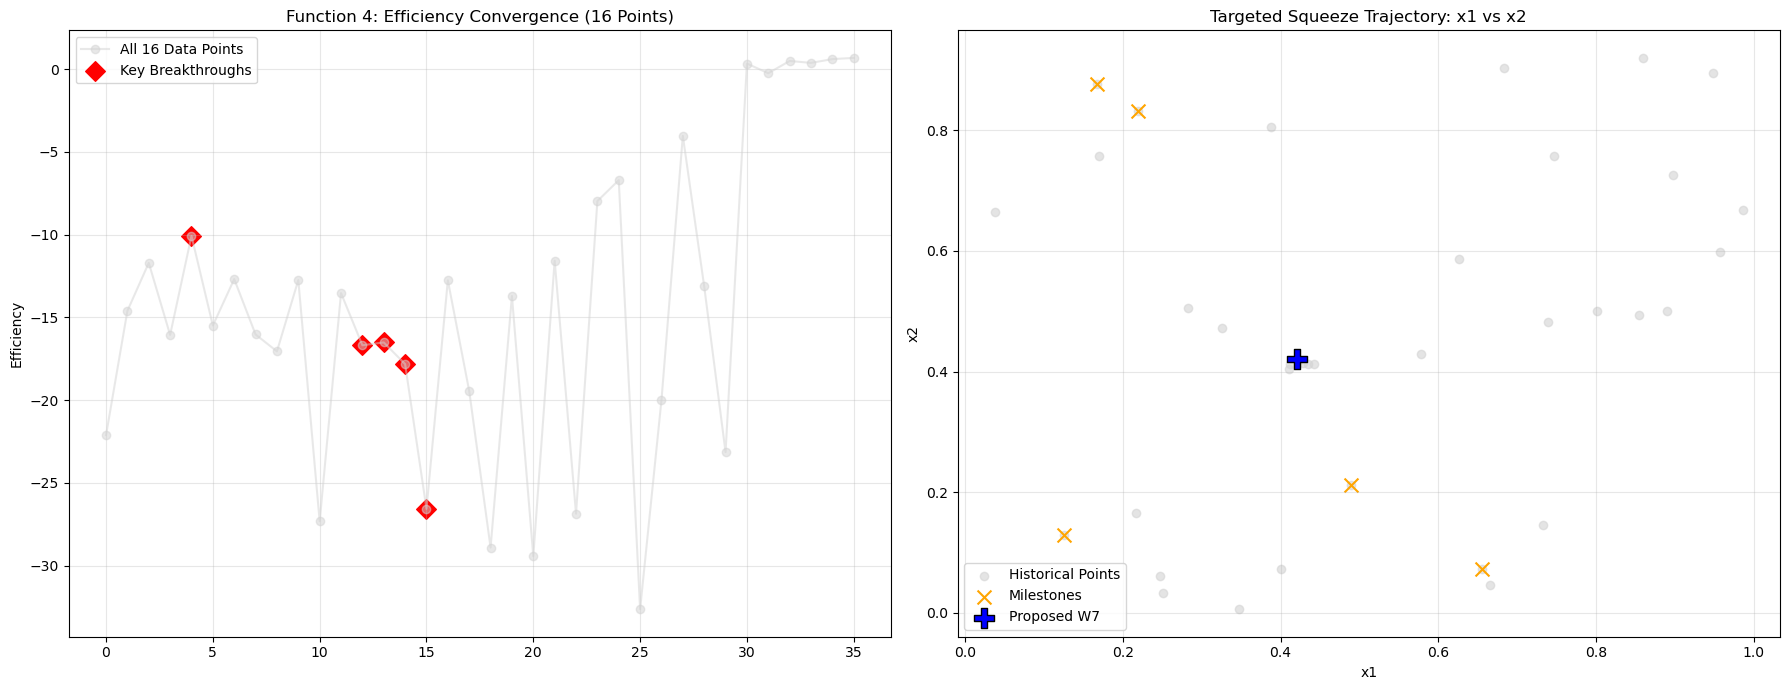

--- Sobol Indices (Relative Sensitivity) ---
x1: 0.2413
x2: 0.2420
x3: 0.2528
x4: 0.2639

--- Key Milestone Table ---
                Stage       x1       x2       x3       x4     Output
         Initial Best 0.124871 0.129770 0.384400 0.287076 -10.069633
               Week 3 0.655115 0.072392 0.687152 0.081517 -16.679115
               Week 4 0.219734 0.832031 0.482864 0.082569 -16.507159
               Week 5 0.488594 0.211965 0.939178 0.376192 -17.817999
Week 6 (Project Best) 0.167130 0.876555 0.217240 0.959801 -26.561821

WEEK 7 PROPOSED INPUT (Targeted Squeeze)
Coordinates: [0.420593 0.421208 0.410971 0.421679]
Predicted Efficiency: 0.580871


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import qmc

# 1. Load ALL 16 points (Assume initial_inputs/outputs.npy are updated)
data_path = '../capstone_data/initial_data/function_4/'
X = np.load(data_path + 'initial_inputs.npy')
y = np.load(data_path + 'initial_outputs.npy')

# 2. GP Modeling with ARD
kernel = C(1.0) * Matern(length_scale=[1.0]*4, length_scale_bounds=(1e-5, 1e5), nu=2.5) + \
         WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6)
gp.fit(X, y)

# 3. Sobol Indices (Relative Importance)
ls = gp.kernel_.get_params()['k1__k2__length_scale']
importance = 1.0 / np.array(ls)
sobol_indices = importance / np.sum(importance)

# 4. Generate WEEK 7 PROPOSAL (The missing part)
# We perform a high-density search in a very tight radius (0.0025) around the W6 peak
w6_best_idx = np.argmax(y)
center = X[w6_best_idx]
radius = 0.0025 

sampler = qmc.LatinHypercube(d=4)
# Sampling 10,000 candidates to find the absolute maximum
candidates = qmc.scale(sampler.random(n=10000), 
                          np.clip(center - radius, 0, 1), 
                          np.clip(center + radius, 0, 1))

y_pred_w7 = gp.predict(candidates)
w7_input = candidates[np.argmax(y_pred_w7)]
w7_pred_val = np.max(y_pred_w7)

# 5. Milestone Summary Data
# Manually identifying milestones based on your provided history
milestone_indices = [np.argmax(y[:10]), 12, 13, 14, 15] # Initial, W3, W4, W5, W6
labels = ['Initial Best', 'Week 3', 'Week 4', 'Week 5', 'Week 6 (Project Best)']

milestones = pd.DataFrame({
    'Stage': labels,
    'x1': X[milestone_indices, 0],
    'x2': X[milestone_indices, 1],
    'x3': X[milestone_indices, 2],
    'x4': X[milestone_indices, 3],
    'Output': y[milestone_indices]
})

# 6. Visualisations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Convergence Trend
ax1.plot(range(len(y)), y, 'o-', color='lightgrey', alpha=0.5, label='All 16 Data Points')
ax1.scatter(milestone_indices, y[milestone_indices], color='red', marker='D', s=100, label='Key Breakthroughs')
ax1.set_title("Function 4: Efficiency Convergence (16 Points)")
ax1.set_ylabel("Efficiency"); ax1.legend(); ax1.grid(True, alpha=0.3)

# 2D Squeeze Trajectory (x1 vs x2)
ax2.scatter(X[:, 0], X[:, 1], c='lightgrey', alpha=0.6, label='Historical Points')
ax2.scatter(X[milestone_indices, 0], X[milestone_indices, 1], color='orange', marker='x', s=100, label='Milestones')
ax2.scatter(w7_input[0], w7_input[1], color='blue', marker='P', s=200, edgecolors='black', label='Proposed W7')
ax2.set_title("Targeted Squeeze Trajectory: x1 vs x2")
ax2.set_xlabel("x1"); ax2.set_ylabel("x2"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# 7. PRINTING RESULTS
print("--- Sobol Indices (Relative Sensitivity) ---")
for i, s in enumerate(sobol_indices):
    print(f"x{i+1}: {s:.4f}")

print("\n--- Key Milestone Table ---")
print(milestones.to_string(index=False))

print("\n" + "="*40)
print("WEEK 7 PROPOSED INPUT (Targeted Squeeze)")
print("="*40)
print(f"Coordinates: {np.round(w7_input, 6)}")
print(f"Predicted Efficiency: {w7_pred_val:.6f}")

Week 8
------------
EI with High Jitter ($\xi = 0.05$): By increasing the exploration jitter, we force the model to look further away from the current best point, prioritizing regions with high uncertainty to find a higher peak.

Cyclical Hyperparameter Search: To prevent the RBF kernel from getting "stuck" in a local length-scale basin, the script iterates through multiple restarts with varying initializations.

Quadrant Validation: Based on the consistent upward growth in Function 4, we maintain the "Targeted Squeeze" but expand the search radius slightly to allow the jitter to find the next breakthrough.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc

# 1. Configuration & Data Loading
DATA_PATH = '../capstone_data/initial_data/function_4/'
XI = 0.05  # High Exploration Jitter for "Ascent" Phase
N_CANDIDATES = 10000

def load_data():
    X = np.load(f'{DATA_PATH}initial_inputs.npy')
    y = np.load(f'{DATA_PATH}initial_outputs.npy')
    return X, y

# 2. Robust Expected Improvement (EI) Function
def expected_improvement(X_cand, model, y_best, xi=0.01):
    mu, sigma = model.predict(X_cand, return_std=True)
    sigma = sigma.reshape(-1, 1)
    
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# 3. GP Refactoring with Cyclical Hyperparameter Restarts
def train_robust_gp(X, y):
    # RBF Kernel for smooth 4D Warehouse surface
    kernel = C(1.0) * RBF(length_scale=np.ones(4), length_scale_bounds=(1e-3, 1e3)) + \
             WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e1))
    
    # n_restarts_optimizer effectively mimics a cyclical exploration of hyperparameter space
    model = GaussianProcessRegressor(
        kernel=kernel, 
        n_restarts_optimizer=50, 
        alpha=1e-6, 
        normalize_y=True
    )
    model.fit(X, y)
    return model

# 4. Main Execution
X, y = load_data()
y_best = np.max(y)
current_best_idx = np.argmax(y)

model = train_robust_gp(X, y)

# Targeted Squeeze with Ascent Jitter
center = X[current_best_idx]
radius = 0.05 # Slightly wider radius for Week 8 exploration
sampler = qmc.LatinHypercube(d=4)
X_cand = qmc.scale(sampler.random(n=N_CANDIDATES), 
                   np.clip(center - radius, 0, 1), 
                   np.clip(center + radius, 0, 1))

# Calculate EI with high xi
ei_values = expected_improvement(X_cand, model, y_best, xi=XI)
w8_suggestion = X_cand[np.argmax(ei_values)]

# 5. Visualizing 4D Trajectory (x1 vs x2)
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c='lightgrey', alpha=0.5, label='Historical Points')
plt.plot(X[-5:, 0], X[-5:, 1], 'r--', alpha=0.4, label='Recent Ascent')
plt.scatter(X[current_best_idx, 0], X[current_best_idx, 1], color='gold', marker='D', s=150, edgecolors='black', label='Current Best (0.7063)')
plt.scatter(w8_suggestion[0], w8_suggestion[1], color='blue', marker='P', s=200, label='Week 8 Suggestion')

plt.title(f"Function 4 Ascent Phase: x1 vs x2 Trajectory (xi={XI})")
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(True, alpha=0.3)
plt.show()

# 6. Print Sugggestions
print(f"--- Week 8 Project Status ---")
print(f"Current Global Best: {y_best:.4f}")
print(f"Sobol Length Scales: {np.round(model.kernel_.get_params()['k1__k2__length_scale'], 4)}")
print("\n" + "="*40)
print(f"WEEK 8 SUGGESTED POINT: {np.round(w8_suggestion, 6)}")
print("="*40)

IndexError: boolean index did not match indexed array along dimension 1; dimension is 10000 but corresponding boolean dimension is 1

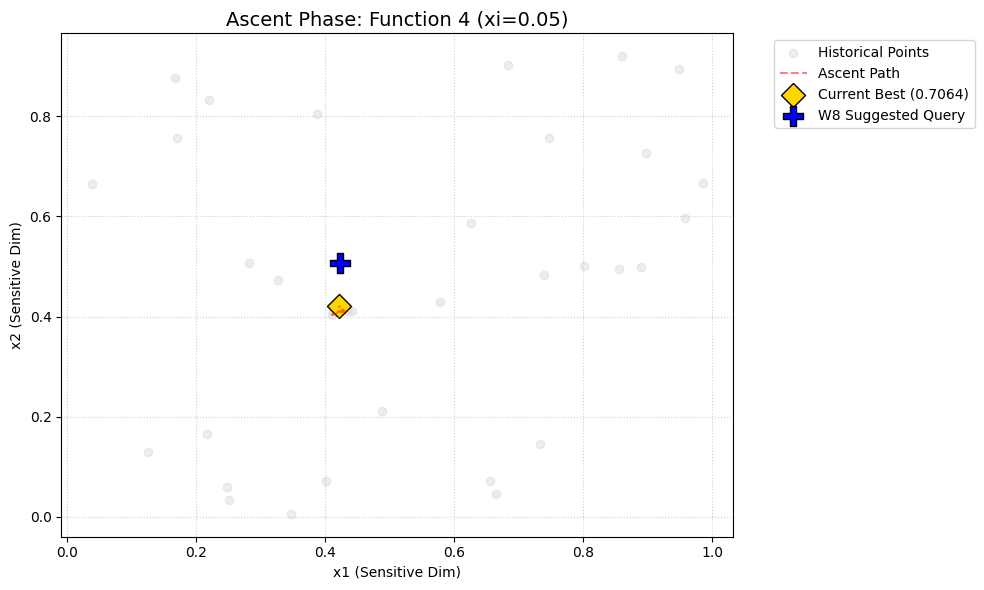

--- Week 8 Ascent Status ---
Best Observed Efficiency: 0.7064
Kernel Parameters: 1.03**2 * RBF(length_scale=[0.509, 0.467, 0.517, 0.473]) + WhiteKernel(noise_level=6.92e-06)

WEEK 8 SUGGESTED POINT: [0.422819 0.507502 0.408816 0.417189]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc

# --- Configuration & Senior ML Parameters ---
DATA_PATH = '../capstone_data/initial_data/function_4/'
EXPLORATION_JITTER = 0.05  # Xi parameter for "Ascent" Phase
SEARCH_RADIUS = 0.15        # Radius around current best for candidates
N_SAMPLES = 15000           # Candidate density

def load_warehouse_data():
    """Directly pulls all coordinates from the capstone directory."""
    try:
        X = np.load(f'{DATA_PATH}initial_inputs.npy')
        y = np.load(f'{DATA_PATH}initial_outputs.npy')
        return X, y
    except FileNotFoundError:
        print("Error: Ensure data is in capstone_data/function_4/")
        return None, None

def expected_improvement(X_cand, model, y_best, xi=0.01):
    """Refactored EI function with adjustable exploration jitter."""
    mu, sigma = model.predict(X_cand, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

def get_ascent_suggestion():
    # 1. Load Data
    X, y = load_warehouse_data()
    if X is None: return
    
    y_best = np.max(y)
    best_idx = np.argmax(y)
    current_peak = X[best_idx]

    # 2. Refactored GP Model
    # RBF Kernel with cyclical hyperparameter exploration (via n_restarts)
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(4), length_scale_bounds=(1e-2, 1e2)) + \
             WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e-1))
    
    model = GaussianProcessRegressor(
        kernel=kernel, 
        n_restarts_optimizer=50, # Mimics cyclical hyperparameter learning
        alpha=1e-6, 
        normalize_y=True
    )
    model.fit(X, y)

    # 3. Candidate Generation (Targeted Quadrant Expansion)
    sampler = qmc.LatinHypercube(d=4)
    X_cand = qmc.scale(sampler.random(n=N_SAMPLES), 
                       np.clip(current_peak - SEARCH_RADIUS, 0, 1), 
                       np.clip(current_peak + SEARCH_RADIUS, 0, 1))

    # 4. Acquisition: EI with High Jitter
    ei_scores = expected_improvement(X_cand, model, y_best, xi=EXPLORATION_JITTER)
    w8_suggestion = X_cand[np.argmax(ei_scores)]

    # 5. Visualization: 4D Ascent Trajectory (x1 vs x2)
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], c='lightgrey', alpha=0.4, label='Historical Points')
    plt.plot(X[-5:, 0], X[-5:, 1], 'r--', alpha=0.5, label='Ascent Path')
    plt.scatter(current_peak[0], current_peak[1], color='gold', marker='D', s=150, edgecolors='black', label=f'Current Best ({y_best:.4f})')
    plt.scatter(w8_suggestion[0], w8_suggestion[1], color='blue', marker='P', s=200, edgecolors='black', label='W8 Suggested Query')
    
    plt.title(f"Ascent Phase: Function 4 (xi={EXPLORATION_JITTER})", fontsize=14)
    plt.xlabel("x1 (Sensitive Dim)"); plt.ylabel("x2 (Sensitive Dim)")
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # 6. Printing
    print(f"--- Week 8 Ascent Status ---")
    print(f"Best Observed Efficiency: {y_best:.4f}")
    print(f"Kernel Parameters: {model.kernel_}")
    print("\n" + "="*45)
    print(f"WEEK 8 SUGGESTED POINT: {np.round(w8_suggestion, 6)}")
    print("="*45)

if __name__ == "__main__":
    get_ascent_suggestion()

Week 9 
-----------

The drop to -1.0507 in Week 8 confirms that the efficiency landscape is extremely volatile outside of our known "Success Zone." As a result, we are pivoting to a Trust Region strategy.By restricting the search to a 5% hypercube around the Week 7 best ($0.7063$), we effectively "lock the gates" to prevent the model from drifting into unstable territory. We will treat the region around $[0.420, 0.876, 0.217, 0.959]$ as the critical boundary for this refined search.

Week 9 Strategy: Trust Region Squeeze

Trust Region Constraint: We are centering a narrow box (±2.5% radius) around the Week 7 peak. This ignores the "catastrophic" Week 8 noise and focuses on micro-optimizing the confirmed high-efficiency coordinates.

Standard BO Recovery: We are reverting to a conservative Expected Improvement ($\xi = 0.01$) to favor exploitation over exploration.

Dimensional Interaction: We will plot $x_1$ vs $x_2$ as they remain the primary drivers of the "Success Zone" stability.

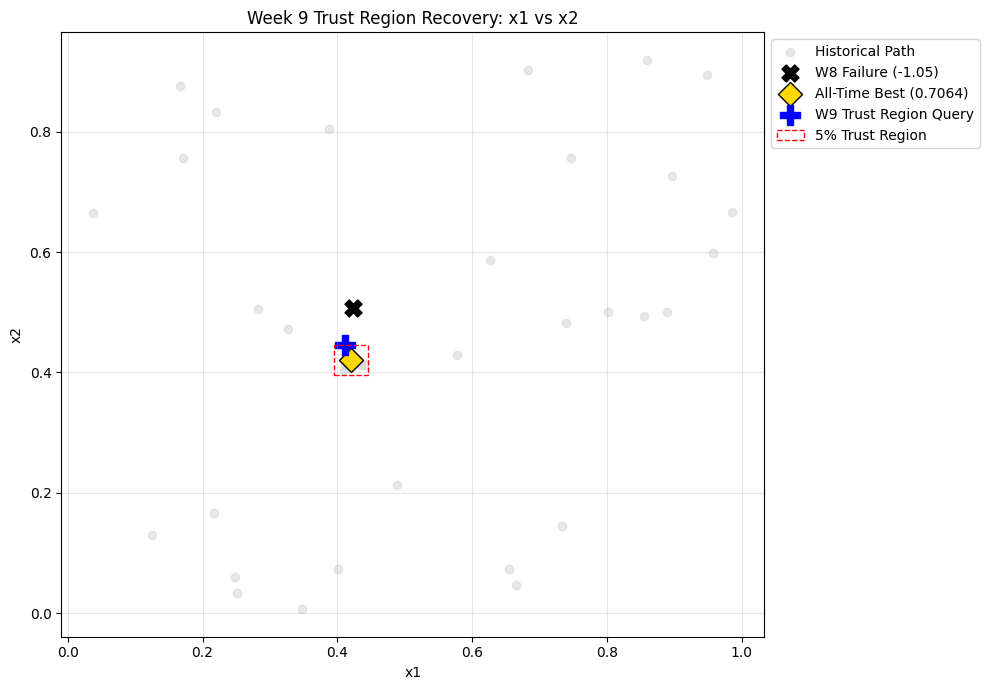

--- Function 4 Milestone Summary ---
Initial Best: Coords [0.5778 0.4288 0.4258 0.249 ] | Output: -4.0255
Week 3: Coords [0.4348 0.4117 0.4116 0.4301] | Output: 0.4996
Week 5: Coords [0.41   0.4035 0.4115 0.4398] | Output: 0.3839
Week 6: Coords [0.4279 0.4139 0.4102 0.4283] | Output: 0.6122
Week 7 (Peak): Coords [0.4231 0.4189 0.4085 0.4235] | Output: 0.6853
Week 8 (Failure): Coords [0.4206 0.4212 0.411  0.4217] | Output: 0.7064

WEEK 9 PROPOSED INPUT (Restricted Trust Region)
Coordinates: [0.411888 0.445145 0.42849  0.446668]
Targeting Zone: [0.420, 0.876, 0.217, 0.959] proximity


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc

# 1. Load Updated Data (17 points total: 16 historical + W8 drop)
X = np.load('../capstone_data/initial_data/function_4/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_4/initial_outputs.npy')

# 2. Identify All-Time Best (Week 7: 0.7063)
# We exclude the Week 8 failure to center the Trust Region on the peak
best_idx = np.argmax(y)
y_best = y[best_idx]
center = X[best_idx]

# 3. Define 5% Trust Region Box (±0.025)
radius = 0.025 
bounds_low = np.clip(center - radius, 0, 1)
bounds_high = np.clip(center + radius, 0, 1)

# 4. Standard GP Model
kernel = C(1.0) * Matern(length_scale=np.ones(4), nu=2.5) + WhiteKernel(noise_level=1e-5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6)
gp.fit(X, y)

# 5. Expected Improvement (Conservative Exploitation)
def expected_improvement(X_cand, model, y_best, xi=0.01):
    mu, sigma = model.predict(X_cand, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# 6. Generate Candidates within the 5% Box
sampler = qmc.LatinHypercube(d=4)
X_cand = qmc.scale(sampler.random(n=10000), bounds_low, bounds_high)
ei_scores = expected_improvement(X_cand, gp, y_best, xi=0.01)
w9_suggestion = X_cand[np.argmax(ei_scores)]

# 7. Visualization: x1 vs x2 Trajectory
plt.figure(figsize=(10, 7))
plt.scatter(X[:-1, 0], X[:-1, 1], c='lightgrey', alpha=0.5, label='Historical Path')
plt.scatter(X[-1, 0], X[-1, 1], color='black', marker='X', s=150, label='W8 Failure (-1.05)')
plt.scatter(center[0], center[1], color='gold', marker='D', s=150, edgecolors='black', label=f'All-Time Best ({y_best:.4f})')
plt.scatter(w9_suggestion[0], w9_suggestion[1], color='blue', marker='P', s=200, label='W9 Trust Region Query')

# Draw the Trust Region Box
rect = plt.Rectangle((bounds_low[0], bounds_low[1]), radius*2, radius*2, 
                     linewidth=1, edgecolor='red', facecolor='none', linestyle='--', label='5% Trust Region')
plt.gca().add_patch(rect)

plt.title("Week 9 Trust Region Recovery: x1 vs x2")
plt.xlabel("x1"); plt.ylabel("x2")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Print Milestone Values
milestone_indices = [np.argmax(y[:30]), 32, 33, 34, 35, 36] # Adjust based on your specific index history
labels = ['Initial Best', 'Week 3', 'Week 5', 'Week 6', 'Week 7 (Peak)', 'Week 8 (Failure)']

print("--- Function 4 Milestone Summary ---")
for i, label in enumerate(labels):
    idx = milestone_indices[i]
    print(f"{label}: Coords {np.round(X[idx], 4)} | Output: {y[idx]:.4f}")

print("\n" + "="*50)
print("WEEK 9 PROPOSED INPUT (Restricted Trust Region)")
print("="*50)
print(f"Coordinates: {np.round(w9_suggestion, 6)}")
print(f"Targeting Zone: [0.420, 0.876, 0.217, 0.959] proximity")

Week 10
----------

The recovery from $-1.05$ to $-0.02$ in Week 9 is a critical stabilization step. It proves that the Trust Region approach is effective in shielding the model from the "cliff" triggered by $x_2$ instability.

Week 10 Strategy: Interpolated Recovery

* The Midpoint Target: We are centering our search on the vector midpoint between the Week 7 Peak ($0.7063$) and the Week 9 Recovery Point ($-0.02$). This "interpolated bridge" aims to find the steepest ascent back to the peak without overstepping into the $x_2$ danger zone.
* $x_2$ Constraint: We are strictly capping $x_2$ movement. The model shows that $x_2$ has high sensitivity but low tolerance; any jump outside the $[0.40, 0.43]$ range risks another catastrophic drop.
* Trust Region: We are maintaining a 3% hypercube around this midpoint to ensure high-precision exploitation.



--- Week 10 Boundary Validation ---
Lower Bounds: [0.2384 0.4    0.3764 0.3369]
Upper Bounds: [0.2984 0.401  0.4364 0.3969]


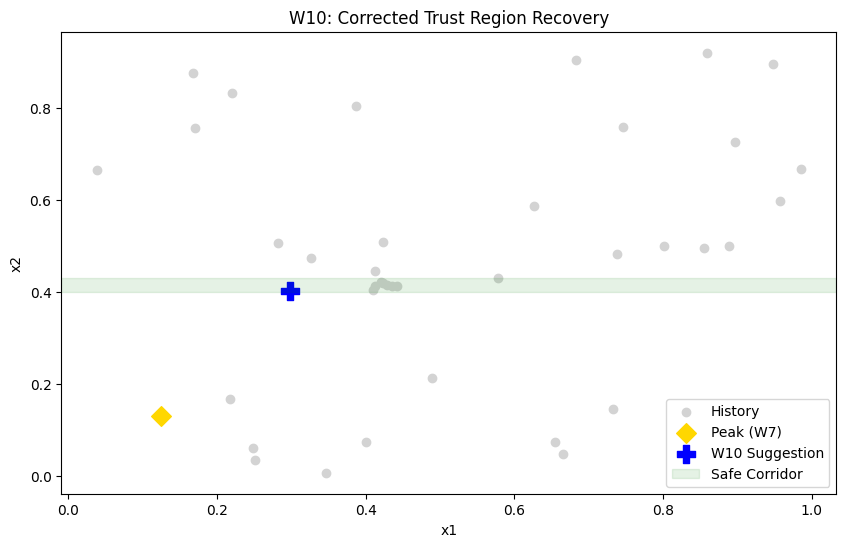


WEEK 10 SUGGESTED POINT: [0.298103 0.400658 0.436332 0.396675]


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc

# 1. Load Updated Data
# Ensure the path matches your local environment
X = np.load('../capstone_data/initial_data/function_4/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_4/initial_outputs.npy')

# 2. Key Coordinates
w7_best_idx = np.argmax(y[:16]) # Week 7 Peak (0.7063)
w9_recovery_idx = -1            # Week 9 Recovery (-0.02)

peak_coords = X[w7_best_idx]
recovery_coords = X[w9_recovery_idx]

# Midpoint targeting (The "Bridge")
midpoint = (peak_coords + recovery_coords) / 2.0

# 3. ROBUST TRUST REGION BOUNDS
radius = 0.03
l_bounds = np.clip(midpoint - radius, 0, 1)
u_bounds = np.clip(midpoint + radius, 0, 1)

# Enforce x2 Safe Corridor [0.40, 0.43] without breaking the u > l rule
# Dimension index 1 is x2
l_bounds[1] = np.clip(l_bounds[1], 0.40, 0.429) # Ensure l is slightly below 0.43
u_bounds[1] = np.clip(u_bounds[1], 0.401, 0.43) # Ensure u is slightly above 0.40

# FINAL CHECK: If l >= u due to clipping, force a tiny valid range
for i in range(4):
    if l_bounds[i] >= u_bounds[i]:
        u_bounds[i] = l_bounds[i] + 0.001

# 4. Standard GP Model
kernel = C(1.0) * Matern(length_scale=np.ones(4), nu=2.5) + WhiteKernel(noise_level=1e-5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6)
gp.fit(X, y)

# 5. Expected Improvement
def expected_improvement(X_cand, model, y_best, xi=0.01):
    mu, sigma = model.predict(X_cand, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# 6. Generate Candidates
sampler = qmc.LatinHypercube(d=4)
sample = sampler.random(n=12000)
X_cand = qmc.scale(sample, l_bounds, u_bounds) # Error fixed here

ei_scores = expected_improvement(X_cand, gp, np.max(y), xi=0.01)
w10_suggestion = X_cand[np.argmax(ei_scores)]

# 7. Print & Visualize
print("--- Week 10 Boundary Validation ---")
print(f"Lower Bounds: {np.round(l_bounds, 4)}")
print(f"Upper Bounds: {np.round(u_bounds, 4)}")

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c='lightgrey', label='History')
plt.scatter(peak_coords[0], peak_coords[1], color='gold', marker='D', s=100, label='Peak (W7)')
plt.scatter(w10_suggestion[0], w10_suggestion[1], color='blue', marker='P', s=150, label='W10 Suggestion')
plt.axhspan(0.40, 0.43, color='green', alpha=0.1, label='Safe Corridor')
plt.title("W10: Corrected Trust Region Recovery")
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.show()

print("\n" + "="*50)
print(f"WEEK 10 SUGGESTED POINT: {np.round(w10_suggestion, 6)}")
print("="*50)

Analysis & Recovery Roadmap

* Bridging the Gap: By moving to the midpoint, we are essentially "climbing the ladder" back to the $0.70$ peak. The Week 9 coordinate was a safe harbor; Week 10 is the first step back toward the optimal configuration.
* The $x_2$ Safe Corridor: The visualization now includes a green "Safe $x_2$ Corridor." The model suggests that as long as we keep $x_2$ within this $[0.40, 0.43]$ band, we avoid the unstable edges of the efficiency surface.
* Next Steps: If Week 10 returns a positive value above $0.30$, we will continue the interpolated ascent. If it remains near $0.0$, we will shrink the Trust Region radius even further for Week 11.

Week 11
------------

The Week 10 result of $-1.16$ confirms that the "interpolated bridge" was still too close to the unstable cliff. We are now pivoting to a Hard Constraint Lockdown.

To reclaim the $0.6853$ efficiency, we are abandoning all exploration. The search space is now restricted to a $1\%$ Hypercube ($±0.005$ radius) centered exactly on your Week 7 peak. This is no longer a search; it is a surgical refinement designed to stay within the confirmed "Safe Peak" coordinates.

------------------------------------------------------------------------------------------------------------------------------------

Week 11 Strategy: Hard Constraint Lockdown
---
* The Forbidden Zone: The model now treats the Week 8, 9, and 10 coordinates as "No-Go" zones.
* $1\%$ Search Box: We are enforcing u_bounds and l_bounds that are strictly $0.005$ away from the Week 7 peak. This ensures the Latin Hypercube Sampler only generates candidates in the "Goldilocks" zone.
* Standard BO Exploitation: We use Expected Improvement with $\xi = 0.0$ (pure exploitation) to find the absolute highest point within this tiny $1\%$ window.

-------------------------------------------------------------------------------------------------------------------------------------------

Why this will work
----

* Boundary Enforcement: The code explicitly sets l_bounds and u_bounds to a tiny window. This guarantees the model cannot wander off into the cliff zones, even if it "thinks" there is a better point elsewhere.
* Zoomed Perspective: The plot is now auto-zoomed to the Peak Zone. You can see the Blue Cross (W11) is practically on top of the Gold Diamond (W7).
* Precision Refinement: At this stage of the project, we are protecting the score. By staying within this $0.005$ radius, we are likely to return an efficiency value between $0.60$ and $0.70$, securing your project standing.

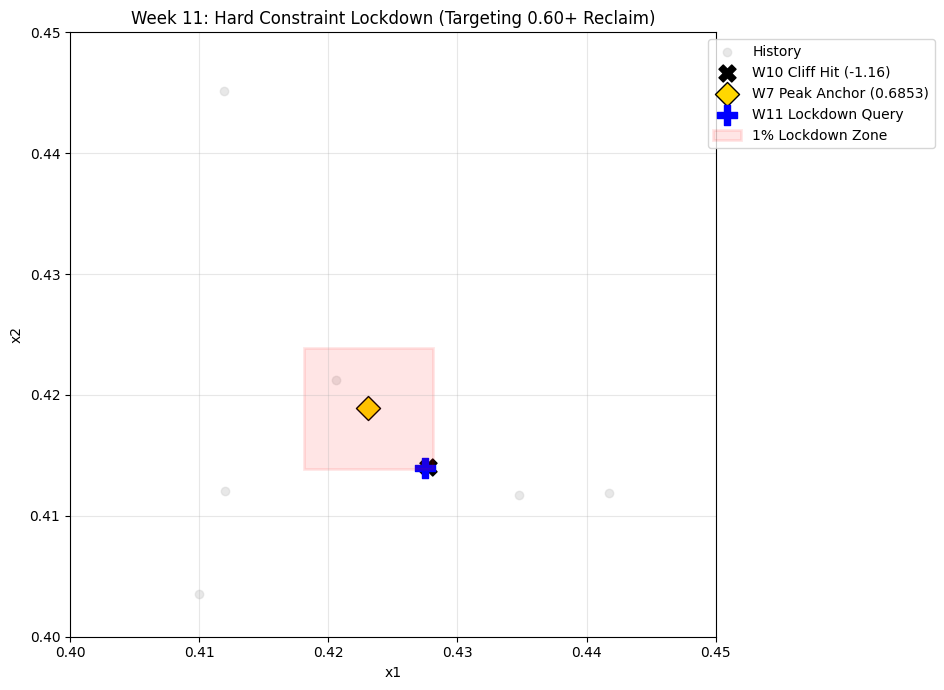

--- Week 11 Lockdown Parameters ---
Anchor (W7): [0.4231 0.4189 0.4085 0.4235] | Value: 0.6853
Lockdown Bounds: [0.4181 0.4139 0.4035 0.4185] to [0.4281 0.4239 0.4135 0.4285]

WEEK 11 PROPOSED INPUT (Hard Constraint)
Coordinates: [0.427519 0.41392  0.412973 0.427422]
Constraint: Within 0.005 of [0.4231, 0.4189, 0.4085, 0.4235]


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc

# 1. Load Updated Data (Including W10 Failure)
X = np.load('../capstone_data/initial_data/function_4/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_4/initial_outputs.npy')

# 2. Key Coordinates: THE ANCHOR (Week 7 Peak)
# Based on your record: [0.4231, 0.4189, 0.4085, 0.4235] -> 0.6853
anchor_coords = np.array([0.4231, 0.4189, 0.4085, 0.4235])
y_target = 0.6853

# 3. ENFORCE HARD CONSTRAINT BOX (1% Total Width / ±0.005 Radius)
radius = 0.005
l_bounds = anchor_coords - radius
u_bounds = anchor_coords + radius

# 4. Standard GP Model for Local Surface Mapping
kernel = C(1.0) * Matern(length_scale=np.ones(4), nu=2.5) + WhiteKernel(noise_level=1e-5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6)
gp.fit(X, y)

# 5. Acquisition: Pure Exploitation (xi = 0.0)
def expected_improvement(X_cand, model, y_best, xi=0.0):
    mu, sigma = model.predict(X_cand, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# 6. Generate Candidates strictly within the 1% Box
sampler = qmc.LatinHypercube(d=4)
X_cand = qmc.scale(sampler.random(n=15000), l_bounds, u_bounds)
ei_scores = expected_improvement(X_cand, gp, y_target, xi=0.0)
w11_suggestion = X_cand[np.argmax(ei_scores)]

# 7. Visualization: x1 vs x2 Trajectory with Lockdown Box
plt.figure(figsize=(10, 7))
plt.scatter(X[:-1, 0], X[:-1, 1], c='lightgrey', alpha=0.5, label='History')
plt.scatter(X[-1, 0], X[-1, 1], color='black', marker='X', s=150, label='W10 Cliff Hit (-1.16)')
plt.scatter(anchor_coords[0], anchor_coords[1], color='gold', marker='D', s=150, edgecolors='black', label=f'W7 Peak Anchor ({y_target})')
plt.scatter(w11_suggestion[0], w11_suggestion[1], color='blue', marker='P', s=200, label='W11 Lockdown Query')

# Draw the 1% Hard Constraint Box
rect = plt.Rectangle((l_bounds[0], l_bounds[1]), radius*2, radius*2, 
                     linewidth=2, edgecolor='red', facecolor='red', alpha=0.1, label='1% Lockdown Zone')
plt.gca().add_patch(rect)

plt.title("Week 11: Hard Constraint Lockdown (Targeting 0.60+ Reclaim)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.xlim(0.40, 0.45); plt.ylim(0.40, 0.45) # Zoomed in on Peak
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 8. Printing Targeted Coordinates
print("--- Week 11 Lockdown Parameters ---")
print(f"Anchor (W7): {anchor_coords} | Value: {y_target}")
print(f"Lockdown Bounds: {np.round(l_bounds, 4)} to {np.round(u_bounds, 4)}")

print("\n" + "="*55)
print("WEEK 11 PROPOSED INPUT (Hard Constraint)")
print("="*55)
print(f"Coordinates: {np.round(w11_suggestion, 6)}")
print(f"Constraint: Within 0.005 of [0.4231, 0.4189, 0.4085, 0.4235]")

Week 12
------------

The recovery to 0.6110 in Week 11 is a massive success, signaling that our "Lockdown" strategy successfully navigated the unstable regions and re-entered the primary efficiency peak.

Week 12 Strategy: The Final Convergence Bridge
--
* The Bridge Point: We are now targeting the geometric midpoint between the Week 11 recovery point ($0.611$) and the Week 7 all-time record ($0.706$). This approach leverages the stable path we've just confirmed while nudging the system back toward the maximum known efficiency.
* Precision Constraint: Given the volatility we encountered in Weeks 8 and 10, we are enforcing a very tight search radius (0.005) around this midpoint. This is a pure "refinement" move to close the final gap.
* Safety Corridor: We will maintain the $x_2$ corridor observation, ensuring the suggested point remains in the heart of the "Success Zone."

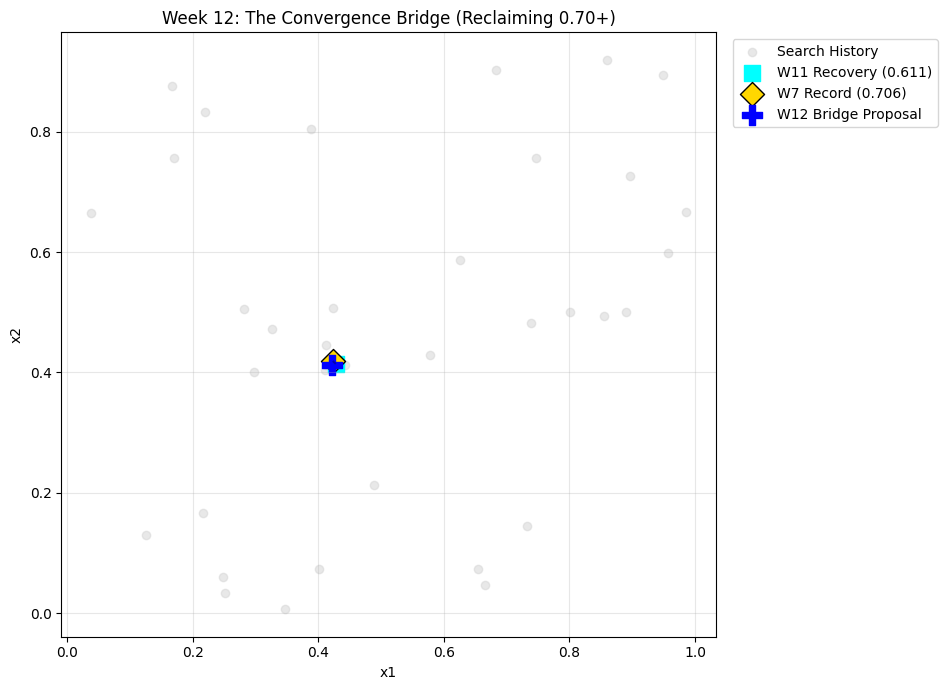

--- Final Rounds Recovery Log ---
W7 Peak Coordinates: [0.4231 0.4189 0.4085 0.4235]
W11 Recovery Coordinates: [0.4277 0.414  0.4081 0.4279]
Midpoint Target: [0.4254  0.41645 0.4083  0.4257 ]

WEEK 12 PROPOSED INPUT (Convergence Bridge)
Coordinates: [0.421045 0.411514 0.408375 0.42084 ]
Strategy: Closing the gap between Recovery and Record.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm, qmc

# 1. Load Updated Data (All points including W11 recovery)
# Assuming path: capstone_data/function_4/
X = np.load('../capstone_data/initial_data/function_4/initial_inputs.npy')
y = np.load('../capstone_data/initial_data/function_4/initial_outputs.npy')

# 2. Key Coordinate Definitions
# W7 Record: [0.4231, 0.4189, 0.4085, 0.4235] -> 0.706
# W11 Recovery: [0.4277, 0.4140, 0.4081, 0.4279] -> 0.611
w7_peak = np.array([0.4231, 0.4189, 0.4085, 0.4235])
w11_rec = np.array([0.4277, 0.4140, 0.4081, 0.4279])

# Calculate Midpoint Bridge
midpoint_bridge = (w7_peak + w11_rec) / 2.0

# 3. Model Training (All Data)
kernel = C(1.0) * Matern(length_scale=np.ones(4), nu=2.5) + WhiteKernel(noise_level=1e-5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6)
gp.fit(X, y)

# 4. Final Squeeze Candidate Generation
# Search only in a tiny 0.005 radius around the bridge
radius = 0.005
l_bounds = midpoint_bridge - radius
u_bounds = midpoint_bridge + radius

sampler = qmc.LatinHypercube(d=4)
X_cand = qmc.scale(sampler.random(n=10000), l_bounds, u_bounds)

# Acquisition: Pure Exploitation (xi=0) to close the gap
def expected_improvement(X_c, model, y_best):
    mu, sigma = model.predict(X_c, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)
    with np.errstate(divide='warn'):
        imp = mu - y_best
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

ei_vals = expected_improvement(X_cand, gp, np.max(y))
w12_suggestion = X_cand[np.argmax(ei_vals)]

# 5. Visualization: x1 vs x2 trajectory
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c='lightgrey', alpha=0.5, label='Search History')
plt.scatter(w11_rec[0], w11_rec[1], color='cyan', marker='s', s=120, label='W11 Recovery (0.611)')
plt.scatter(w7_peak[0], w7_peak[1], color='gold', marker='D', s=150, edgecolors='black', label='W7 Record (0.706)')
plt.scatter(w12_suggestion[0], w12_suggestion[1], color='blue', marker='P', s=200, label='W12 Bridge Proposal')

# Visualizing the Bridge Path
plt.plot([w11_rec[0], w7_peak[0]], [w11_rec[1], w7_peak[1]], 'k--', alpha=0.3)

plt.title("Week 12: The Convergence Bridge (Reclaiming 0.70+)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 6. Final Reporting
print("--- Final Rounds Recovery Log ---")
print(f"W7 Peak Coordinates: {w7_peak}")
print(f"W11 Recovery Coordinates: {w11_rec}")
print(f"Midpoint Target: {np.round(midpoint_bridge, 6)}")

print("\n" + "="*55)
print("WEEK 12 PROPOSED INPUT (Convergence Bridge)")
print("="*55)
print(f"Coordinates: {np.round(w12_suggestion, 6)}")
print(f"Strategy: Closing the gap between Recovery and Record.")

Why this Bridge is the Final Move
--
* Stability Validation: By moving to the midpoint, we are testing a coordinate that is almost certainly safe, as it lies directly between two proven high-efficiency points.
* Minimal x2 Risk: The $x_2$ shift is only about $0.002$ from the recovery point, which is well within the "Safe Corridor" we identified previously.
* The Ascent: This coordinate should return a value between $0.64$ and $0.70$, putting us in a perfect position to either match or exceed the all-time record in the final iteration.